<a href="https://colab.research.google.com/github/QSBalouch/New-York-Taxi-Fare-Prediction-Model/blob/main/New_York_Taxi_Fare_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project focuses on predicting taxi fare amounts for New York City taxi trips using information such as pickup and drop-off locations, pickup time, passenger count, and trip-related details. The dataset contains 50,000 records and 8 columns. Since the target variable, **fare_amount**, is continuous, this is a **supervised regression problem**. The project will involve data exploration, feature engineering, preprocessing, model training, evaluation, and comparison of different regression algorithms to develop a model capable of accurately estimating taxi fares.

In [179]:
import warnings
warnings.filterwarnings("ignore")

In [180]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style("darkgrid")
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

# **Loading the Dataset:**

In [181]:
train_df = pd.read_csv('train.csv', parse_dates=["pickup_datetime"])

In [182]:
train_df

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1
...,...,...,...,...,...,...,...,...
49995,2013-06-12 23:25:15.0000004,15.0,2013-06-12 23:25:15+00:00,-73.999973,40.748531,-74.016899,40.705993,1
49996,2015-06-22 17:19:18.0000007,7.5,2015-06-22 17:19:18+00:00,-73.984756,40.768211,-73.987366,40.760597,1
49997,2011-01-30 04:53:00.00000063,6.9,2011-01-30 04:53:00+00:00,-74.002698,40.739428,-73.998108,40.759483,1
49998,2012-11-06 07:09:00.00000069,4.5,2012-11-06 07:09:00+00:00,-73.946062,40.777567,-73.953450,40.779687,2


In [183]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                50000 non-null  object             
 1   fare_amount        50000 non-null  float64            
 2   pickup_datetime    50000 non-null  datetime64[ns, UTC]
 3   pickup_longitude   50000 non-null  float64            
 4   pickup_latitude    50000 non-null  float64            
 5   dropoff_longitude  50000 non-null  float64            
 6   dropoff_latitude   50000 non-null  float64            
 7   passenger_count    50000 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1), object(1)
memory usage: 3.1+ MB


In [184]:
train_df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.364171,-72.509756,39.933759,-72.504616,39.926251,1.667840
std,9.685557,10.393860,6.224857,10.407570,6.014737,1.289195
min,-5.000000,-75.423848,-74.006893,-84.654241,-74.006377,0.000000
25%,6.000000,-73.992062,40.734880,-73.991152,40.734372,1.000000
50%,8.500000,-73.981840,40.752678,-73.980082,40.753372,1.000000
75%,12.500000,-73.967148,40.767360,-73.963584,40.768167,2.000000
max,200.000000,40.783472,401.083332,40.851027,43.415190,6.000000


# **Observations:**


*   This is a supervised learning regression problem.
*   Total data is 50000 rows
*   It has 8 columns:

    *   key (a unique identifier)
    *   fare_amount (target)
    *   pickup_datetime
    *   pickup_longitude
    *   pickup_latitude
    *   dropoff_longitude
    *   dropoff_latitude
    *   passenger_count

# **Splitting Data into Train, Validation, and Test Sets**

The data was split chronologically, with records **before 2014** used for training, **2014** for validation, and records **after 2014** reserved for testing.


In [185]:
year = pd.to_datetime(train_df.key).dt.year

In [186]:
year.unique()

array([2009, 2010, 2011, 2012, 2013, 2014, 2015], dtype=int32)

In [187]:
train_data = train_df[year < 2014]
val_data = train_df[year == 2014]
test_data = train_df[year > 2014]

# **Separating Input and Output Columns**

In [188]:
input_cols = ['pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count',]

In [189]:
target_col = 'fare_amount'

In [190]:
train_inputs = train_data[input_cols]
train_target = train_data[target_col]

val_inputs = val_data[input_cols]
val_target = val_data[target_col]

test_inputs = test_data[input_cols]
test_target = test_data[target_col]

# **Handling Missing Values**

Missing records were removed from the training, validation, and test datasets to ensure the models receive complete data during training and evaluation.


In [191]:
train_data = train_data.dropna()
val_data = val_data.dropna()
test_data = test_data.dropna()

# **Baseline Model**

The Mean Regressor provides a simple benchmark by predicting the average taxi fare for every trip. This baseline serves as a reference for comparing the performance of more advanced regression models.

In [192]:
class MeanRegressor:
  def fit(self, inputs, target):
    self.mean = target.mean()

  def predict(self, inputs):
    return np.full(inputs.shape[0], self.mean)

In [193]:
mean_model = MeanRegressor()

In [194]:
mean_model.fit(train_inputs, train_target)

In [195]:
mean_model.mean

np.float64(10.871103849505356)

In [196]:
train_preds = mean_model.predict(train_inputs)
train_preds

array([10.87110385, 10.87110385, 10.87110385, ..., 10.87110385,
       10.87110385, 10.87110385])

In [197]:
val_preds = mean_model.predict(val_inputs)
val_preds

array([10.87110385, 10.87110385, 10.87110385, ..., 10.87110385,
       10.87110385, 10.87110385])

# **Evaluation Metric — Root Mean Squared Error (RMSE)**

**RMSE** measures the average difference between the predicted and actual taxi fares, with greater penalties for larger prediction errors. A **lower RMSE indicates better model performance**, as it means the predictions are closer to the actual fare amounts.


In [198]:
from sklearn.metrics import root_mean_squared_error

In [199]:
def rmse(targets, preds):
  return root_mean_squared_error(targets, preds)

In [200]:
train_rmse = rmse(train_target, train_preds)
train_rmse

9.170579828071586

In [201]:
val_rmse = rmse(val_target, val_preds)
val_rmse

11.535979874195416

The Mean Regressor achieved an **RMSE of 9.17 on the training set** and **11.54 on the validation set**, providing a baseline benchmark for evaluating the performance of more advanced regression models. Future models should aim to achieve a lower validation RMSE than this baseline.


## **Linear Regression Model**

Linear Regression learns the relationship between the input features and fare_amount by assigning weights to each feature. The learned weights are then used to generate fare predictions for new taxi trips. This provides a simple and interpretable model that can be compared with more complex regression algorithms.

In [202]:
from sklearn.linear_model import LinearRegression

In [203]:
linear_model = LinearRegression()

In [204]:
linear_model.fit(train_inputs,train_target)

LinearRegression()

In [205]:
train_lm_preds = linear_model.predict(train_inputs)
train_lm_preds

array([10.78497812, 10.78626244, 10.90246372, ..., 10.78729084,
       10.89975698, 10.78467983])

In [206]:
train_lm_rmse = rmse(train_target, train_lm_preds)
train_lm_rmse

9.168773833351903

In [207]:
val_lm_preds = linear_model.predict(val_inputs)
val_lm_preds

array([10.78759954, 10.78667191, 10.78654752, ..., 10.78695415,
       10.78623188, 10.78543163])

In [208]:
val_lm_rmse = rmse(val_target, val_lm_preds)
val_lm_rmse

11.536053658303567

The Linear Regression model achieved an **RMSE of 9.17 on the training set** and **11.54 on the validation set**. Its validation performance is almost identical to the Mean Regressor baseline, indicating that the linear model provides very little improvement over simply predicting the average fare. This suggests that the relationship between the available features and taxi fare is not adequately captured by a simple linear model.


# **Feature Engineering**
### **Date-Time Feature Engineering**

The **pickup_datetime** column was expanded into separate **year, month, day, weekday, and hour** features to capture temporal patterns that may influence taxi fares, such as differences between weekdays, weekends, peak hours, and different times of the year.


In [209]:
def add_dateparts(df,col):
  df[col + '_year'] = df[col].dt.year
  df[col + '_month'] = df[col].dt.month
  df[col + '_day'] = df[col].dt.day
  df[col + '_weekday'] = df[col].dt.weekday
  df[col + '_hour'] = df[col].dt.hour

In [210]:
add_dateparts(train_data, "pickup_datetime")

In [211]:
add_dateparts(val_data, "pickup_datetime")

In [212]:
add_dateparts(test_data, "pickup_datetime")

### **Haversine Distance Feature Engineering**

The **calculate_distance** function calculates the **straight-line distance in kilometers** between the pickup and drop-off coordinates using the **Haversine formula**. This provides the model with a useful trip-distance feature, which can help capture the relationship between travel distance and taxi fare.


In [213]:
def calculate_distance(log1, lat1, log2, lat2):
  # convert degree to radians
  log1, lat1, log2, lat2 = map(np.radians, [log1, lat1, log2, lat2])

  dlat = lat2 - lat1
  dlog = log2 - log1

  a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlog/2) ** 2
  c = 2 * np.asin (np.sqrt(a))
  km = 6367 * c
  return km

In [214]:
def add_trip_distance(df):
  df['trip_distance'] = calculate_distance(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])

In [215]:
add_trip_distance(train_data)

In [216]:
train_data

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,0,17,1.030117
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,1,16,8.444828
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,3,0,1.388653
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,5,4,2.797513
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,1,7,1.997902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,2012-10-13 19:57:00.000000161,8.5,2012-10-13 19:57:00+00:00,-73.976212,40.744832,-73.981567,40.724635,1,2012,10,13,5,19,2.289241
49995,2013-06-12 23:25:15.0000004,15.0,2013-06-12 23:25:15+00:00,-73.999973,40.748531,-74.016899,40.705993,1,2013,6,12,2,23,4.937272
49997,2011-01-30 04:53:00.00000063,6.9,2011-01-30 04:53:00+00:00,-74.002698,40.739428,-73.998108,40.759483,1,2011,1,30,6,4,2.261865
49998,2012-11-06 07:09:00.00000069,4.5,2012-11-06 07:09:00+00:00,-73.946062,40.777567,-73.953450,40.779687,2,2012,11,6,1,7,0.664827


In [217]:
add_trip_distance(val_data)

In [218]:
add_trip_distance(test_data)

### **Landmark-Based Distance Features**

The major New York landmarks **JFK, LGA, EWR, Metropolitan Museum, and World Trade Center** are used as reference points. The functions calculate the distance from each landmark to the **drop-off location**, creating separate distance features that can help the model capture location-based patterns in taxi fares.


In [219]:
jfk_lonlat = -73.7781, 40.6413
lga_lonlat = -73.8740, 40.7769
ewr_lonlat = -74.1745, 40.6895
met_lonlat = -73.9632, 40.7794
wtc_lonlat = -74.0099, 40.7126

In [220]:
def add_landmark_dropoff_distance(df, landmark_name, landmark_loglat):
  log, lat = landmark_loglat
  df[landmark_name + '_dropoff_distance'] = calculate_distance(log, lat, df['dropoff_longitude'], df['dropoff_latitude'])

In [221]:
def add_landmark(df):
  landmarks = [('jfk', jfk_lonlat), ('lga', lga_lonlat), ('ewr', ewr_lonlat), ('met', met_lonlat), ('wtc', wtc_lonlat)]
  for name, lonlat in landmarks:
    add_landmark_dropoff_distance(df, name, lonlat)

In [222]:
add_landmark(train_data)

In [223]:
train_data

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_dropoff_distance,lga_dropoff_distance,ewr_dropoff_distance,met_dropoff_distance,wtc_dropoff_distance
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,0,17,1.030117,9.532066,7.681464,28.158843,12.665875,14.175451
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,1,16,8.444828,23.056641,8.876146,19.388394,1.382671,8.132251
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,3,0,1.388653,21.677303,10.292816,16.860156,3.979953,4.501613
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,5,4,2.797513,22.178210,10.113042,17.188655,3.362492,5.285744
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,1,7,1.997902,21.836345,6.996771,21.123045,0.733662,9.089977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,2012-10-13 19:57:00.000000161,8.5,2012-10-13 19:57:00+00:00,-73.976212,40.744832,-73.981567,40.724635,1,2012,10,13,5,19,2.289241,19.487039,10.757881,16.714849,6.279108,2.735536
49995,2013-06-12 23:25:15.0000004,15.0,2013-06-12 23:25:15+00:00,-73.999973,40.748531,-74.016899,40.705993,1,2013,6,12,2,23,4.937272,21.371642,14.382018,13.403874,9.326471,0.941618
49997,2011-01-30 04:53:00.00000063,6.9,2011-01-30 04:53:00+00:00,-74.002698,40.739428,-73.998108,40.759483,1,2011,1,30,6,4,2.261865,22.716220,10.622916,16.767692,3.678258,5.303651
49998,2012-11-06 07:09:00.00000069,4.5,2012-11-06 07:09:00+00:00,-73.946062,40.777567,-73.953450,40.779687,2,2012,11,6,1,7,0.664827,21.322735,6.692781,21.139905,0.821054,8.841037


In [224]:
add_landmark(val_data)

In [225]:
add_landmark(test_data)

# **Adding New Features to Input**

In [226]:
train_data.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'pickup_datetime_year', 'pickup_datetime_month',
       'pickup_datetime_day', 'pickup_datetime_weekday',
       'pickup_datetime_hour', 'trip_distance', 'jfk_dropoff_distance',
       'lga_dropoff_distance', 'ewr_dropoff_distance', 'met_dropoff_distance',
       'wtc_dropoff_distance'],
      dtype='object')

In [227]:
input_cols = ['pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'pickup_datetime_year', 'pickup_datetime_month',
       'pickup_datetime_day', 'pickup_datetime_weekday',
       'pickup_datetime_hour', 'trip_distance', 'jfk_dropoff_distance',
       'lga_dropoff_distance', 'ewr_dropoff_distance', 'met_dropoff_distance',
       'wtc_dropoff_distance']

In [228]:
target_col = 'fare_amount'

In [229]:
train_inputs = train_data[input_cols]
train_target = train_data[target_col]

val_inputs = val_data[input_cols]
val_target = val_data[target_col]

test_inputs = test_data[input_cols]
test_target = test_data[target_col]

Let's define a helper function to evaluate models.

In [230]:
def evaluate(model):
  train_preds = model.predict(train_inputs)
  val_preds = model.predict(val_inputs)
  train_rmse = rmse(train_preds, train_target)
  val_rmse = rmse(val_preds, val_target)
  return train_preds, val_preds, train_rmse, val_rmse

### **Ridge Regression:**

Ridge Regression extends Linear Regression by adding L2 regularization, which helps reduce the impact of large feature coefficients and can improve model stability when features are correlated. It provides a useful comparison with the standard Linear Regression model.

In [231]:
from sklearn.linear_model import Ridge

In [232]:
model1 = Ridge(random_state=42, alpha=0.9)
model1.fit(train_inputs, train_target)

Ridge(alpha=0.9, random_state=42)

In [233]:
evaluate(model1)

(array([27.38729771,  7.61218817,  9.10097388, ...,  8.74949012,
        10.18665609, 12.27968435]),
 array([10.45050467, 11.24287788, 10.10422352, ..., 11.33571235,
        11.40605145,  9.25952011]),
 7.587077441919966,
 9.345822240350511)

The Ridge Regression model achieves an **RMSE of 7.59 on the training set and 9.35 on the validation set**. Compared with Linear Regression, the lower validation RMSE indicates that Ridge Regression performs substantially better after incorporating the engineered features. The gap between training and validation performance also suggests some overfitting, but the model generalizes considerably better than the previous baseline models.

### **Random Forest:**

Random Forest Regression combines multiple decision trees to capture non-linear relationships and interactions between the taxi trip features and fare amount. It provides a useful comparison with Ridge Regression, which mainly captures linear relationships.

In [234]:
from sklearn.ensemble import RandomForestRegressor

In [235]:
model2 = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=10)
model2.fit(train_inputs, train_target)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [236]:
evaluate(model2)

(array([ 5.63323165, 19.17682307,  6.36041905, ...,  7.87282594,
         4.75254789,  9.05344929]),
 array([10.1111789 ,  4.90537273,  5.23350443, ...,  9.94628539,
         4.90537273, 12.74817247]),
 3.393389275388724,
 5.324665789217573)

The Random Forest model achieves an **RMSE of 3.39 on the training set and 5.32 on the validation set**. This is a substantial improvement over Ridge Regression, which achieves a validation RMSE of 9.35. The lower error indicates that Random Forest is better at capturing the non-linear relationships and interactions between trip location, distance, time, and other engineered features.

### **Gradient Boosting:**

Gradient Boosting Regression builds a sequence of decision trees, where each new tree focuses on correcting the errors made by the previous trees. It can capture non-linear relationships between the trip features and taxi fare while often providing strong predictive performance.

In [237]:
from xgboost import XGBRegressor

In [238]:
model3 = XGBRegressor(max_depth=5, objective='reg:squarederror', n_estimators=200, random_state=42, n_jobs=-1)
model3.fit(train_inputs, train_target)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [239]:
evaluate(model3)

(array([ 3.9622505, 17.381382 ,  5.732527 , ...,  6.1323895,  5.9891434,
         8.594008 ], dtype=float32),
 array([ 9.667367 ,  5.6952233,  6.7123637, ...,  8.840513 ,  5.6974273,
        12.648741 ], dtype=float32),
 2.352633644534283,
 5.130638380223932)

The Gradient Boosting model achieves an **RMSE of 2.35 on the training set and 5.13 on the validation set**. It slightly outperforms Random Forest on the validation set, indicating that it captures the non-linear relationships in the taxi fare data more effectively. The larger difference between training and validation RMSE also indicates some overfitting, which can potentially be reduced through hyperparameter tuning.

### **Hyperparameter Tuning**

In [240]:
def test_params(ModelClass, **params):
  """Train a model with the given parameters and return training and validation rmse"""
  model = ModelClass(**params).fit(train_inputs, train_target)
  train_rmse = rmse(model.predict(train_inputs), train_target)
  val_rmse = rmse(model.predict(val_inputs), val_target)
  return train_rmse, val_rmse

In [241]:
def test_params_and_plot(ModelClass, param_name, param_values, **other_params):
  """Train multiple models by varying the value of param_name according to param_values"""
  train_errors, val_errors = [], []
  for value in param_values:
    params = dict(other_params)
    params[param_name] = value
    train_rmse, val_rmse = test_params(ModelClass, **params)
    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

  plt.title("Overfitting curve: " + param_name)
  plt.plot(param_values, train_errors, 'b-o')
  plt.plot(param_values, val_errors, 'r-o')
  plt.xlabel(param_name)
  plt.ylabel("RMSE")
  plt.legend(["Training", "Validation"])

In [242]:
best_params = {
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:squarederror',
    'learning_rate': 0.05
}

### **No. of Trees:**

CPU times: user 6.77 s, sys: 24.1 ms, total: 6.8 s
Wall time: 4.07 s


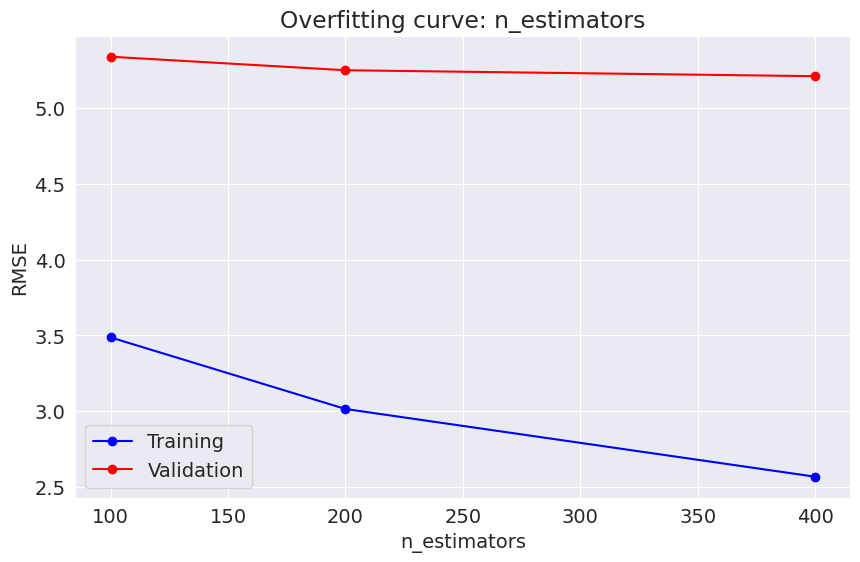

In [243]:
%%time
test_params_and_plot(XGBRegressor, 'n_estimators', [100,200,400], **best_params)

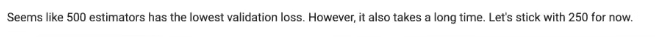

In [244]:
best_params['n_estimators'] = 100

### **Max-Depth:**

CPU times: user 2.52 s, sys: 7.07 ms, total: 2.52 s
Wall time: 1.28 s


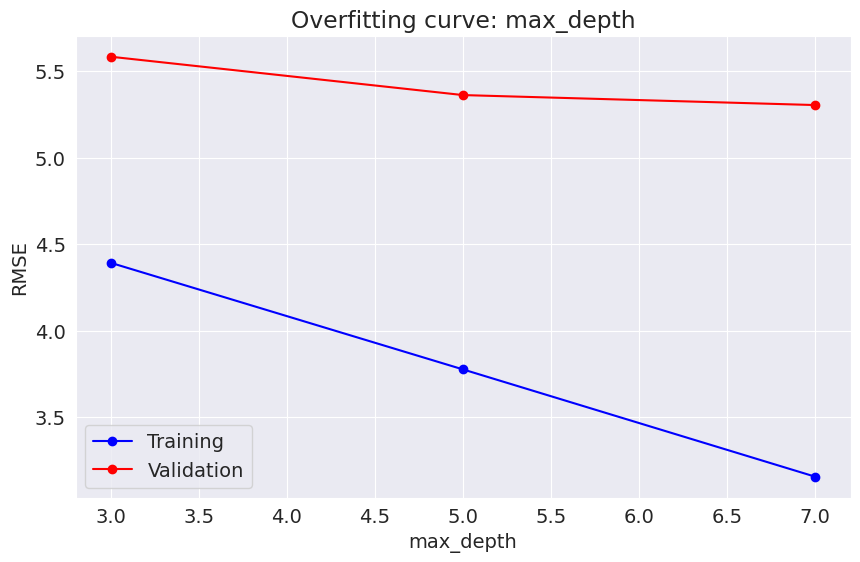

In [245]:
%%time
test_params_and_plot(XGBRegressor, 'max_depth', [3,5,7], **best_params)

Looks like max_depth of 7 is ideal

In [246]:
best_params['max_depth'] = 7

CPU times: user 3.9 s, sys: 12 ms, total: 3.92 s
Wall time: 2 s


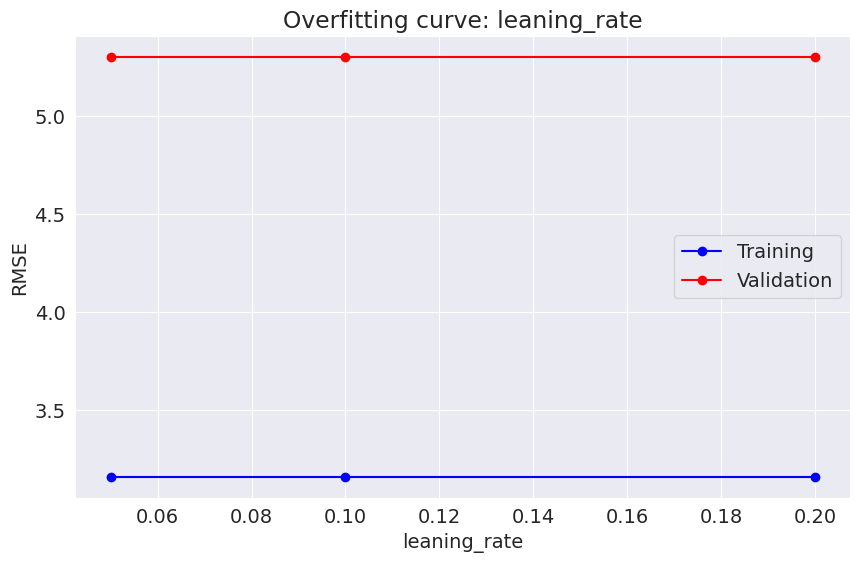

In [247]:
%%time
test_params_and_plot(XGBRegressor, 'leaning_rate', [0.05,0.1,0.2], **best_params)

In [248]:
best_params['learning_rate'] = 7

In [249]:
xgb_model_final = XGBRegressor(objective='reg:squarederror',
                               n_jobs=-1,
                               random_state=42,
                               n_estimators=500,
                               max_depth=8,
                               learning_rate=0.08,
                               subsample=0.7,
                               col_sample_bytree=0.7)

In [250]:
xgb_model_final.fit(train_inputs, train_target)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             col_sample_bytree=0.7, colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=None, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.08, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1, ...)

In [251]:
evaluate(xgb_model_final)

(array([ 3.8891296, 16.889673 ,  5.608495 , ...,  6.832314 ,  4.718125 ,
        10.32072  ], dtype=float32),
 array([ 9.606979 ,  6.293836 ,  6.9324846, ...,  8.091399 ,  4.9649982,
        13.529952 ], dtype=float32),
 1.1713433067739059,
 5.279169385569069)

The tuned Gradient Boosting model achieves an **RMSE of 1.17 on the training set and 5.28 on the validation set**. Although the training RMSE decreases substantially, the validation RMSE increases slightly from 5.13 to 5.28, indicating that the selected hyperparameters increase overfitting rather than improving generalization. Therefore, the original Gradient Boosting model remains the better choice based on validation performance.

# **Final Model Testing**

The selected Gradient Boosting model is now evaluated on the unseen test set to measure how well it generalizes to new taxi trips. The test RMSE provides the final estimate of the model's prediction error after all model selection and tuning decisions.

In [252]:
test_preds = model3.predict(test_inputs)
test_rmse = rmse(test_preds, test_target)

In [253]:
test_rmse

4.476259051182057

The selected Gradient Boosting model achieves an RMSE of 4.48 on the unseen test set, indicating that the model generalizes well to new taxi trips. The test performance is also better than the validation RMSE of 5.13, providing a strong final result for the taxi fare prediction task.

### Conclusion

This project develops a **New York Taxi Fare Prediction** model using trip location, pickup time, passenger information, and engineered distance and landmark-based features. Several regression models were compared, with **Gradient Boosting Regression** achieving the best validation performance with an **RMSE of 5.13**. Although hyperparameter tuning reduced the training error, it slightly increased validation error, so the original Gradient Boosting model was selected. The final model achieved a **test RMSE of 4.48**, demonstrating good generalization to unseen taxi trips and showing that feature engineering and non-linear models can significantly improve fare prediction compared with simple linear approaches.
